# Preprocessing (siRNAs)

This preprocessing step audits and cleans a TSV of siRNA sequences (and optional efficacy). It standardizes columns, detects common data issues (whitespace, invalid characters, mixed lengths, duplicates), and can export a QC report plus an optional cleaned dataset ready for modeling.

Input (TSV): Must contain a sequence column (any name; auto-normalized to sequence). Optional efficacy column (auto-normalized to efficacy).

What it checks:

Leading/trailing and internal whitespace in sequences

Missing/empty sequences

Character inventory (A/C/G/U by default; optional N/IUPAC; flags unknowns; optional detection of DNA T)

Length distribution; reports if all sequences are the same length

Duplicates (entire rows and duplicate sequences)

Efficacy sanity (numeric coercion; out-of-range values; same sequence with multiple efficacy values)

Outputs:

sirna_qc_issues.tsv — rows with any flagged issue (with raw vs cleaned sequence, length, whitespace flags, invalid chars)

sirna_clean.tsv — optional cleaned export after applying your policy (e.g., convert T→U, keep only A/C/G/U, enforce target length)

Config knobs (edit in code): allowed alphabet (RNA-only vs allow N/IUPAC), CONVERT_T_TO_U, TARGET_LEN, dedup policy.

Quick start:

Run steps in order: load → whitespace checks → missing → character audit → length/dups → efficacy checks → write reports.

Review sirna_qc_issues.tsv; adjust policy flags; then export sirna_clean.tsv.

Notes:

Column names are lowercased/trimmed; closest match to “sequence/efficacy” is auto-renamed.

No destructive edits are applied until the explicit cleanup step.

Tailor allowed characters/length to your assay design (e.g., enforce 21-mers).

In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

import matplotlib.pyplot as plt

/Users/darsa/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# >>> change this to your file
tsv_path = Path("../data/siRNAs_cleaned_input.txt")

# Load
df = pd.read_csv(tsv_path, sep="\t", dtype=str)  # read as strings first; we'll coerce later
print("Loaded:", tsv_path.resolve(), "shape:", df.shape)

Loaded: /Users/darsa/Downloads/7_hackathon_NIA_2025/data/siRNAs_cleaned_input.txt shape: (4435, 4)


In [3]:
df

,S.No,Sense,Antisense,Efficiacy
0,SM4439,UUUCACUACUCCUACGAGCTT,GCUCGUAGGAGUAGUGAAATT,0
1,SM4831,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0
2,SM4835,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0
3,SM4474,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0
4,SM4480,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0
...,...,...,...,...
4430,SM5150,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.7
4431,SM5175,CACAAUGCAUUUAGAUCAAUU,UUGAUCUAAAUGCAUUGUGUU,98.76
4432,SM5142,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.81
4433,SM4582,CUUACGCUGAGUACUUCGATT,UCGAAGUACUCAGCGUAAGTT,99


In [4]:
df.columns

Index(['S.No', 'Sense', 'Antisense', 'Efficiacy'], dtype='object')

In [5]:
def unique_chars(series: pd.Series) -> set:
    chars = set()
    for v in series:
        s = "" if v is None else str(v)  # keep raw; do NOT strip/upper so spaces/rare chars are included
        chars.update(s)
    return chars

sense_set = unique_chars(df['Sense'])
antisense_set = unique_chars(df['Antisense'])

In [6]:
sense_set

{' ', '+', 'A', 'C', 'G', 'T', 'U', 'X', 'Y'}

In [7]:
antisense_set

{'0', 'A', 'C', 'G', 'T', 'U', 'X', 'Y', 'a', 'n'}

In [8]:
# Raw length (counts every character, including spaces/tabs/newlines)
df["sense_len_raw"] = df["Sense"].astype(str).str.len()
df["antisense_len_raw"] = df["Antisense"].astype(str).str.len()
df

,S.No,Sense,Antisense,Efficiacy,sense_len_raw,antisense_len_raw
0,SM4439,UUUCACUACUCCUACGAGCTT,GCUCGUAGGAGUAGUGAAATT,0,21,21
1,SM4831,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21
2,SM4835,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21
3,SM4474,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21
4,SM4480,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21
...,...,...,...,...,...,...
4430,SM5150,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.7,21,21
4431,SM5175,CACAAUGCAUUUAGAUCAAUU,UUGAUCUAAAUGCAUUGUGUU,98.76,21,21
4432,SM5142,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.81,21,21
4433,SM4582,CUUACGCUGAGUACUUCGATT,UCGAAGUACUCAGCGUAAGTT,99,21,21


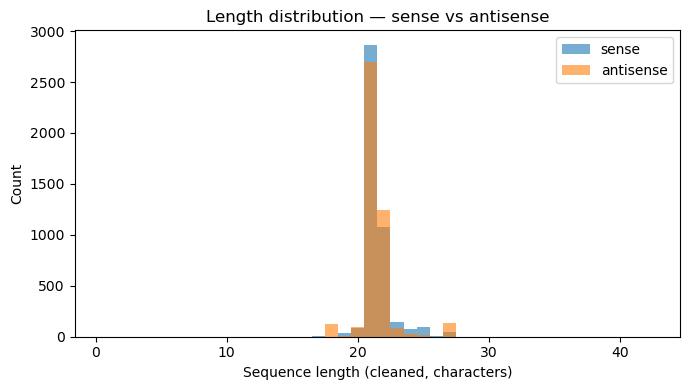

In [9]:
# Integer-aligned bins so each length is centered
min_len = int(min(df["sense_len_raw"].min(), df["antisense_len_raw"].min()))
max_len = int(max(df["sense_len_raw"].max(), df["antisense_len_raw"].max()))
bins = np.arange(min_len - 0.5, max_len + 1.5, 1)

plt.figure(figsize=(7, 4))
plt.hist(df["sense_len_raw"].dropna(), bins=bins, alpha=0.6, label="sense")
plt.hist(df["antisense_len_raw"].dropna(), bins=bins, alpha=0.6, label="antisense")
plt.xlabel("Sequence length (cleaned, characters)")
plt.ylabel("Count")
plt.title("Length distribution — sense vs antisense")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Sanitizer function
def clean_sequence(seq: str) -> str:
    if not isinstance(seq, str):
        return ""
    # Lowercase
    s = seq.lower()
    # Replace unwanted characters (commas, plus, whitespace, etc.) with empty string
    s = re.sub(r"[\s,+]", "", s)
    # Replace any character outside atgcx with 'x'
    s = re.sub(r"[^atgcx]", "x", s)
    return s

# Apply cleaning to sense and antisense columns
df["sense_clean"] = df["Sense"].astype(str).apply(clean_sequence)
df["antisense_clean"] = df["Antisense"].astype(str).apply(clean_sequence)
df

,S.No,Sense,Antisense,Efficiacy,sense_len_raw,antisense_len_raw,sense_clean,antisense_clean
0,SM4439,UUUCACUACUCCUACGAGCTT,GCUCGUAGGAGUAGUGAAATT,0,21,21,xxxcacxacxccxacgagctt,gcxcgxaggagxagxgaaatt
1,SM4831,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21,xgaaxcagaagaxgaagxcaa,gacxxcaxcxxcxgaxxcaag
2,SM4835,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21,xgaaxcagaagaxgaagxcaa,gacxxcaxcxxcxgaxxcaag
3,SM4474,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21,xccxacagcacaacaaaxgxg,caxxxgxxgxgcxgxaggaag
4,SM4480,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21,xccxacagcacaacaaaxgxg,caxxxgxxgxgcxgxaggaag
...,...,...,...,...,...,...,...,...
4430,SM5150,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.7,21,21,ccagxaaggcxxcxcxxaaxx,xxaagagaagccxxacxggxx
4431,SM5175,CACAAUGCAUUUAGAUCAAUU,UUGAUCUAAAUGCAUUGUGUU,98.76,21,21,cacaaxgcaxxxagaxcaaxx,xxgaxcxaaaxgcaxxgxgxx
4432,SM5142,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.81,21,21,ccagxaaggcxxcxcxxaaxx,xxaagagaagccxxacxggxx
4433,SM4582,CUUACGCUGAGUACUUCGATT,UCGAAGUACUCAGCGUAAGTT,99,21,21,cxxacgcxgagxacxxcgatt,xcgaagxacxcagcgxaagtt


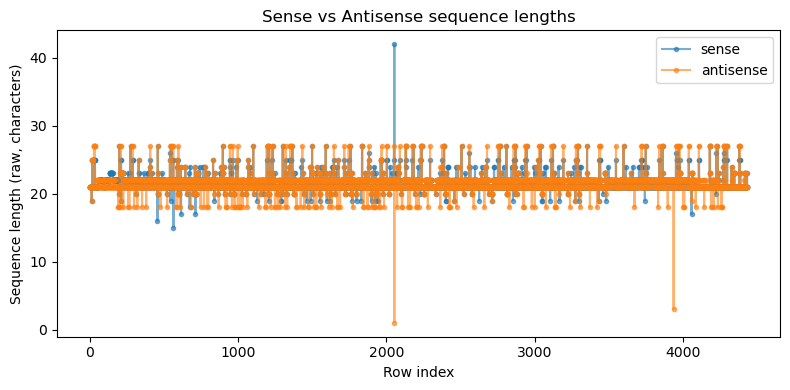

In [11]:
# Assumes you already computed raw lengths
df["sense_len_raw"] = df["Sense"].astype(str).str.len()
df["antisense_len_raw"] = df["Antisense"].astype(str).str.len()


# --- Combined line plot (sense vs antisense) ---
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["sense_len_raw"], marker=".", linestyle="-", alpha=0.6, label="sense")
plt.plot(df.index, df["antisense_len_raw"], marker=".", linestyle="-", alpha=0.6, label="antisense")
plt.xlabel("Row index")
plt.ylabel("Sequence length (raw, characters)")
plt.title("Sense vs Antisense sequence lengths")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Function to pad sequences with 'z' to length 24
def pad_to_len(seq: str, target_len: int = 24) -> str:
    if not isinstance(seq, str):
        seq = ""
    seq = seq.lower()
    if len(seq) < target_len:
        seq = seq + "z" * (target_len - len(seq))
    return seq[:target_len]  # trim if longer than 24

# Apply to cleaned sense and antisense columns
df["sense_24len"] = df["sense_clean"].apply(pad_to_len)
df["antisense_24len"] = df["antisense_clean"].apply(pad_to_len)

# Sanity check
df


,S.No,Sense,Antisense,Efficiacy,sense_len_raw,antisense_len_raw,sense_clean,antisense_clean,sense_24len,antisense_24len
0,SM4439,UUUCACUACUCCUACGAGCTT,GCUCGUAGGAGUAGUGAAATT,0,21,21,xxxcacxacxccxacgagctt,gcxcgxaggagxagxgaaatt,xxxcacxacxccxacgagcttzzz,gcxcgxaggagxagxgaaattzzz
1,SM4831,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21,xgaaxcagaagaxgaagxcaa,gacxxcaxcxxcxgaxxcaag,xgaaxcagaagaxgaagxcaazzz,gacxxcaxcxxcxgaxxcaagzzz
2,SM4835,UGAAUCAGAAGAUGAAGUCAA,GACUUCAUCUUCUGAUUCAAG,0,21,21,xgaaxcagaagaxgaagxcaa,gacxxcaxcxxcxgaxxcaag,xgaaxcagaagaxgaagxcaazzz,gacxxcaxcxxcxgaxxcaagzzz
3,SM4474,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21,xccxacagcacaacaaaxgxg,caxxxgxxgxgcxgxaggaag,xccxacagcacaacaaaxgxgzzz,caxxxgxxgxgcxgxaggaagzzz
4,SM4480,UCCUACAGCACAACAAAUGUG,CAUUUGUUGUGCUGUAGGAAG,0,21,21,xccxacagcacaacaaaxgxg,caxxxgxxgxgcxgxaggaag,xccxacagcacaacaaaxgxgzzz,caxxxgxxgxgcxgxaggaagzzz
...,...,...,...,...,...,...,...,...,...,...
4430,SM5150,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.7,21,21,ccagxaaggcxxcxcxxaaxx,xxaagagaagccxxacxggxx,ccagxaaggcxxcxcxxaaxxzzz,xxaagagaagccxxacxggxxzzz
4431,SM5175,CACAAUGCAUUUAGAUCAAUU,UUGAUCUAAAUGCAUUGUGUU,98.76,21,21,cacaaxgcaxxxagaxcaaxx,xxgaxcxaaaxgcaxxgxgxx,cacaaxgcaxxxagaxcaaxxzzz,xxgaxcxaaaxgcaxxgxgxxzzz
4432,SM5142,CCAGUAAGGCUUCUCUUAAUU,UUAAGAGAAGCCUUACUGGUU,98.81,21,21,ccagxaaggcxxcxcxxaaxx,xxaagagaagccxxacxggxx,ccagxaaggcxxcxcxxaaxxzzz,xxaagagaagccxxacxggxxzzz
4433,SM4582,CUUACGCUGAGUACUUCGATT,UCGAAGUACUCAGCGUAAGTT,99,21,21,cxxacgcxgagxacxxcgatt,xcgaagxacxcagcgxaagtt,cxxacgcxgagxacxxcgattzzz,xcgaagxacxcagcgxaagttzzz


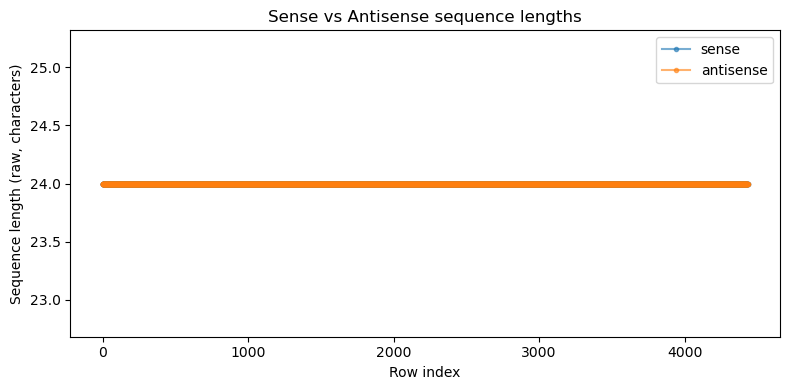

In [13]:
# Assumes you already computed raw lengths
df["sense_24len_value"] = df["sense_24len"].astype(str).str.len()
df["antisense_24len_value"] = df["antisense_24len"].astype(str).str.len()


# --- Combined line plot (sense vs antisense) ---
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["sense_24len_value"], marker=".", linestyle="-", alpha=0.6, label="sense")
plt.plot(df.index, df["antisense_24len_value"], marker=".", linestyle="-", alpha=0.6, label="antisense")
plt.xlabel("Row index")
plt.ylabel("Sequence length (raw, characters)")
plt.title("Sense vs Antisense sequence lengths")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Select fianl colums
cols_to_save = ["sense_24len", "antisense_24len", "Efficiacy"]
df_out = df[cols_to_save].copy()
df_out

,sense_24len,antisense_24len,Efficiacy
0,xxxcacxacxccxacgagcttzzz,gcxcgxaggagxagxgaaattzzz,0
1,xgaaxcagaagaxgaagxcaazzz,gacxxcaxcxxcxgaxxcaagzzz,0
2,xgaaxcagaagaxgaagxcaazzz,gacxxcaxcxxcxgaxxcaagzzz,0
3,xccxacagcacaacaaaxgxgzzz,caxxxgxxgxgcxgxaggaagzzz,0
4,xccxacagcacaacaaaxgxgzzz,caxxxgxxgxgcxgxaggaagzzz,0
...,...,...,...
4430,ccagxaaggcxxcxcxxaaxxzzz,xxaagagaagccxxacxggxxzzz,98.7
4431,cacaaxgcaxxxagaxcaaxxzzz,xxgaxcxaaaxgcaxxgxgxxzzz,98.76
4432,ccagxaaggcxxcxcxxaaxxzzz,xxaagagaagccxxacxggxxzzz,98.81
4433,cxxacgcxgagxacxxcgattzzz,xcgaagxacxcagcgxaagttzzz,99


In [15]:
out_path = Path("../data/sirna_final_sequences_24length_4_input.tsv")
df_out.to_csv(out_path, sep="\t", index=False)

# End of this file 
We got the file with siRNA sequences, both sense and antisen and 